In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [2]:

# Load dataset
movies = pd.read_csv('tmdb_5000_movies.csv')

movies.head()


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [3]:

# Dataset shape
movies.shape


(4803, 20)

In [19]:
# null values
movies.isnull().sum()

budget                     0
genres                     0
homepage                3091
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
Cluster                    0
dtype: int64

In [5]:

# Select features
features = [
    'budget',
    'popularity',
    'revenue',
    'runtime',
    'vote_average',
    'vote_count'
]

X = movies[features]

# Handle missing values
X = X.fillna(0)

X.head()


,budget,popularity,revenue,runtime,vote_average,vote_count
0,237000000,150.437577,2787965087,162.0,7.2,11800
1,300000000,139.082615,961000000,169.0,6.9,4500
2,245000000,107.376788,880674609,148.0,6.3,4466
3,250000000,112.312950,1084939099,165.0,7.6,9106
4,260000000,43.926995,284139100,132.0,6.1,2124



# Outlier Detection

Outliers can heavily affect K-Means because K-Means depends on distance calculations.

We will use:
- Boxplots
- IQR Method

to detect outliers.


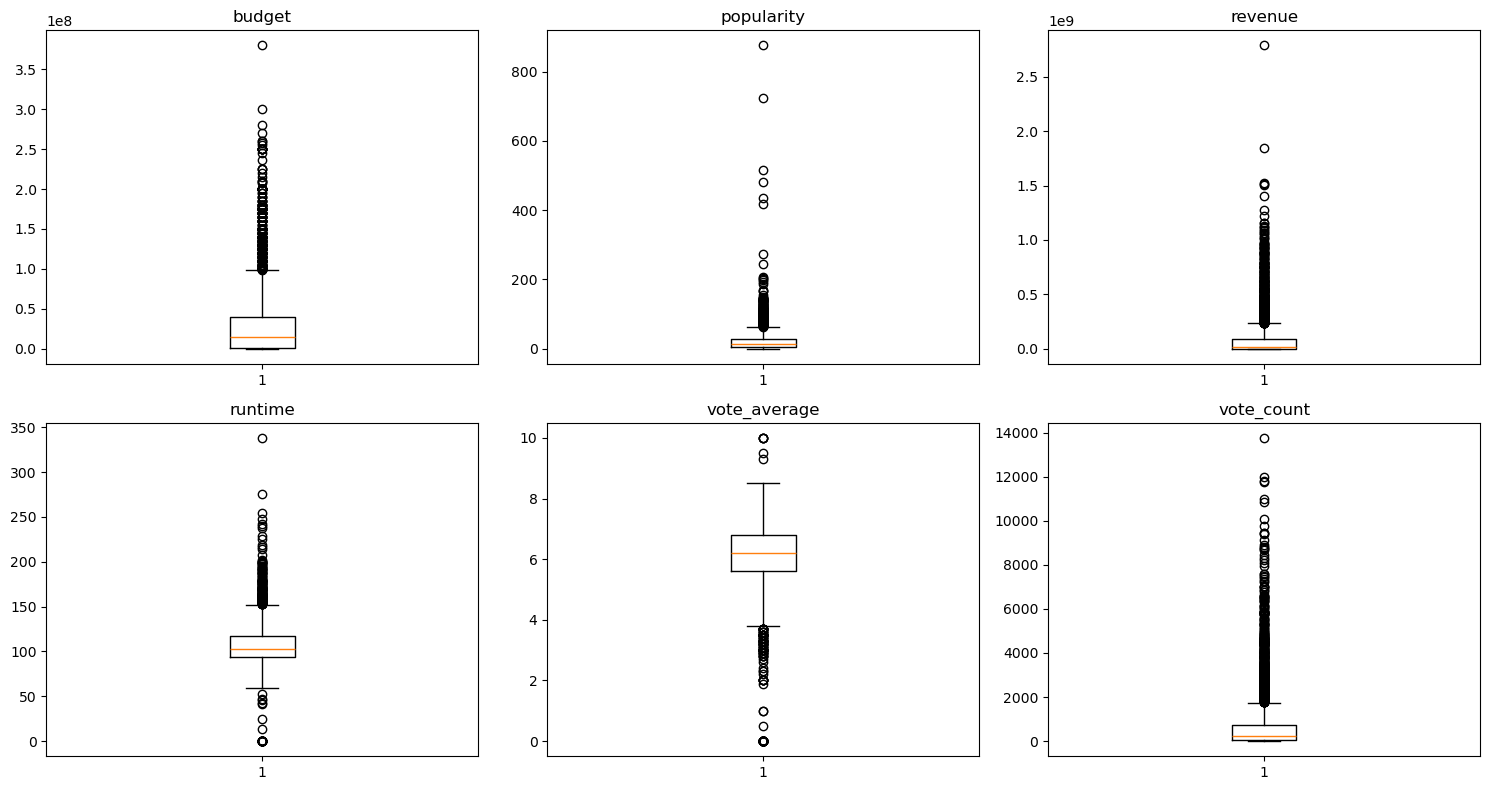

In [6]:

# Boxplots for outlier detection

plt.figure(figsize=(15,8))

for i, column in enumerate(features):
    plt.subplot(2, 3, i+1)
    plt.boxplot(X[column])
    plt.title(column)

plt.tight_layout()
plt.show()


In [7]:

# Detect outliers using IQR method

for column in features:

    Q1 = X[column].quantile(0.25)
    Q3 = X[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = X[(X[column] < lower_bound) | (X[column] > upper_bound)]

    print(f"{column} Outliers: ", len(outliers))


budget Outliers:  321
popularity Outliers:  275
revenue Outliers:  472
runtime Outliers:  203
vote_average Outliers:  156
vote_count Outliers:  504



# Outlier Handling

Instead of removing rows completely, we use:
- Capping Method

This preserves dataset size and reduces extreme values.


In [8]:

# Outlier treatment using capping

for column in features:

    Q1 = X[column].quantile(0.25)
    Q3 = X[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    X[column] = np.where(
        X[column] > upper_bound,
        upper_bound,
        X[column]
    )

    X[column] = np.where(
        X[column] < lower_bound,
        lower_bound,
        X[column]
    )

print("Outliers handled successfully!")


Outliers handled successfully!


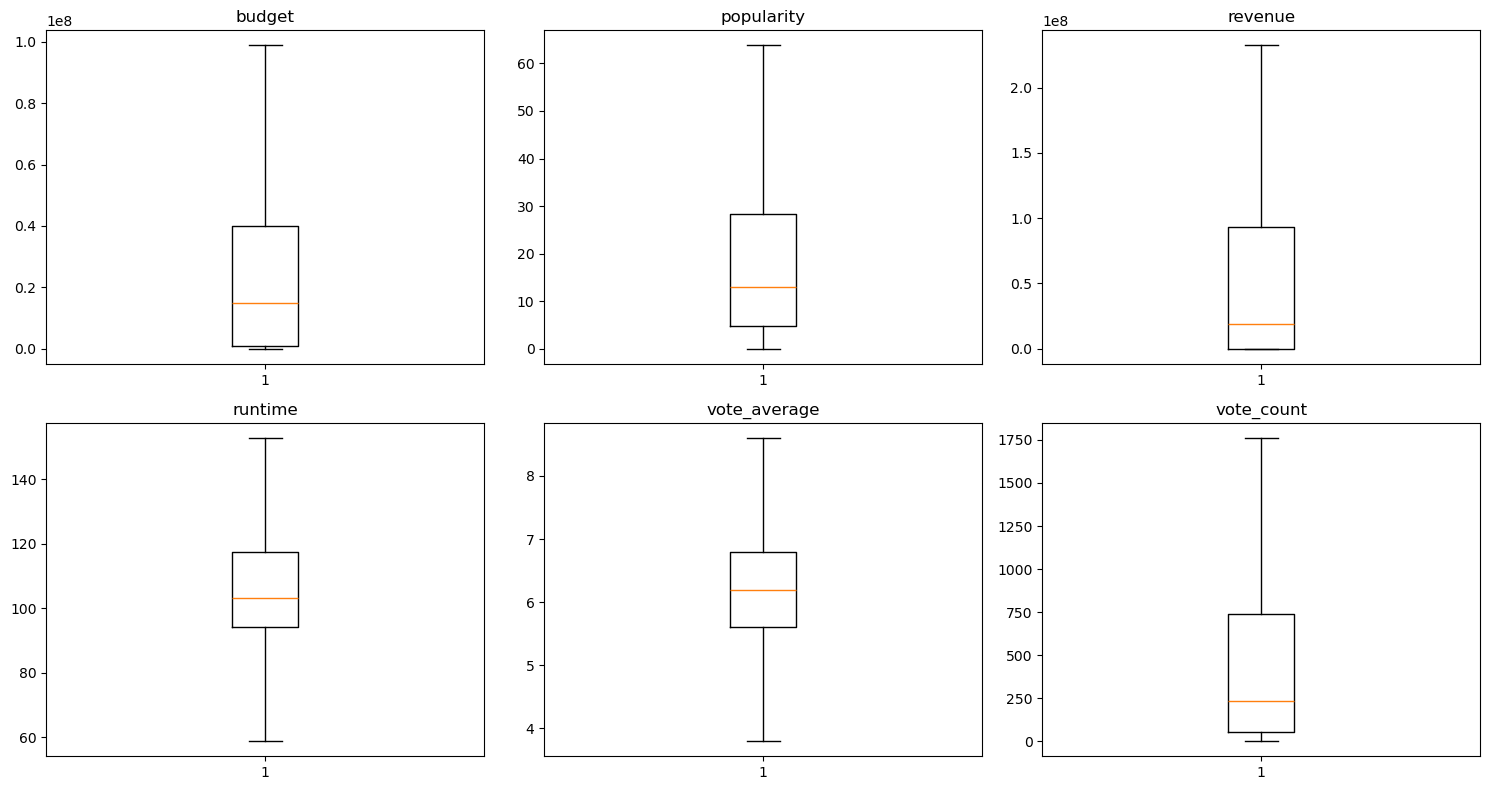

In [21]:

# Boxplots after outlier handling

plt.figure(figsize=(15,8))

for i, column in enumerate(features):
    plt.subplot(2, 3, i+1)
    plt.boxplot(X[column])
    plt.title(column)

plt.tight_layout()
plt.show()



# Feature Scaling

K-Means depends on distance.

So scaling is important.


In [22]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [23]:

# Feature scaling

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled


array([[ 2.42675485,  2.43413722,  2.23199899,  2.52602189,  1.09389351,
         2.17486406],
       [ 2.42675485,  2.43413722,  2.23199899,  2.52602189,  0.780005  ,
         2.17486406],
       [ 2.42675485,  2.43413722,  2.23199899,  2.26622216,  0.15222798,
         2.17486406],
       ...,
       [-0.85596403, -0.96459463, -0.75387087,  0.73477114,  0.88463451,
        -0.84572394],
       [-0.85596403, -0.99662441, -0.75387087, -0.4685118 , -0.47554905,
        -0.84400329],
       [-0.85596403, -0.93812939, -0.75387087, -0.90606923,  0.15222798,
        -0.82851751]], shape=(4803, 6))

In [24]:

# Apply K-Means using business logic

model = KMeans(n_clusters=5, random_state=42)

movies['Cluster'] = model.fit_predict(X_scaled)

movies[['title', 'Cluster']].head()


,title,Cluster
0,Avatar,2
1,Pirates of the Caribbean: At World's End,2
2,Spectre,2
3,The Dark Knight Rises,2
4,John Carter,2


In [25]:

# Movies count in each cluster

movies['Cluster'].value_counts()


Cluster
3    1684
1    1313
0     770
4     545
2     491
Name: count, dtype: int64

In [26]:

# Display movies from Cluster 0

movies[movies['Cluster'] == 0][['title', 'Cluster']].head(20)


,title,Cluster
58,Rush Hour 3,0
73,Evan Almighty,0
104,Poseidon,0
131,G-Force,0
135,The Wolfman,0
141,Mars Needs Moms,0
142,Flushed Away,0
151,Beowulf,0
155,Fun with Dick and Jane,0
162,Stealth,0



# Movie Recommendation System



In [27]:

# Recommend movies

movie_name = 'Avatar'

movie_cluster = movies[movies['title'] == movie_name]['Cluster'].values[0]

recommendations = movies[
    movies['Cluster'] == movie_cluster
][['title', 'Cluster']]

recommendations.head(10)


,title,Cluster
0,Avatar,2
1,Pirates of the Caribbean: At World's End,2
2,Spectre,2
3,The Dark Knight Rises,2
4,John Carter,2
5,Spider-Man 3,2
6,Tangled,2
7,Avengers: Age of Ultron,2
8,Harry Potter and the Half-Blood Prince,2
9,Batman v Superman: Dawn of Justice,2


In [30]:

# Cluster centers

model.cluster_centers_


array([[ 0.89895688,  0.16615274,  0.54549466,  0.13105737, -0.21478847,
         0.04356075],
       [-0.53557607, -0.69585968, -0.62237704, -0.75965049, -1.10316658,
        -0.68030881],
       [ 2.0101122 ,  1.77627453,  2.06400243,  0.7034136 ,  0.41135115,
         1.8891165 ],
       [-0.55802558, -0.49945815, -0.5622698 ,  0.19099918,  0.54409157,
        -0.52599401],
       [-0.07089874,  1.38535792,  0.60454769,  0.41997511,  0.90983021,
         1.50212129]])

In [31]:

# Save clustered dataset

movies.to_csv('clustered_movies.csv', index=False)

print('Clustered dataset saved successfully!')


Clustered dataset saved successfully!


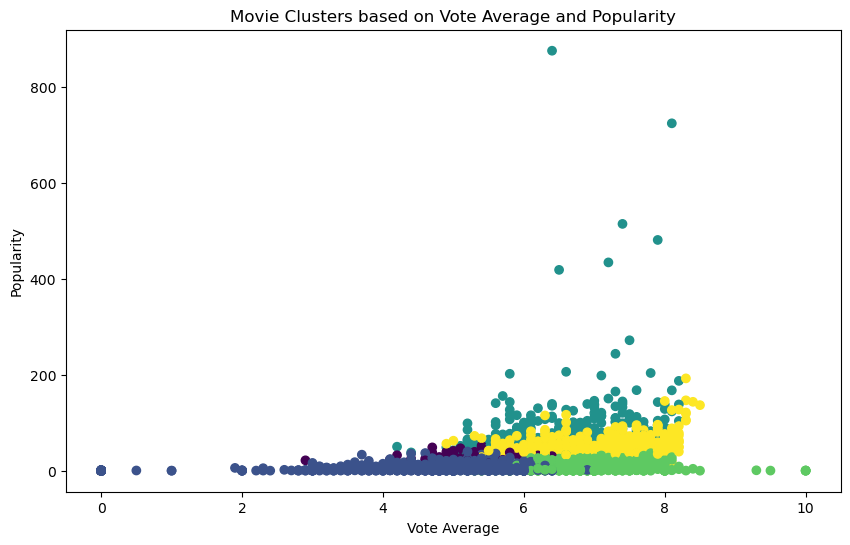

In [33]:
# showing clusters of vote_average and popularity
plt.figure(figsize=(10,6))
plt.scatter(movies['vote_average'], movies['popularity'], c=movies['Cluster'], cmap='viridis')
plt.xlabel('Vote Average')
plt.ylabel('Popularity')
plt.title('Movie Clusters based on Vote Average and Popularity')
plt.show()
